# **Pneumonia Detection from Chest X-Ray Images using Deep Learning**

# **Bussiness case**

Develop a machine learning model that can  classify the x-ray image of chest

# **Dataset**
You can use this real medical dataset.Images are grayscale chest X-rays like the one you uploaded.There are two types of images pneumonia and normal.
link:https://d3ilbtxij3aepc.cloudfront.net/projects/CNN-PROJECT-7-11/Chest-Xray-2.zip

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Import Required Libraries**

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


# **Load dataset**

In [3]:
base_dir = "/content/drive/MyDrive/Chest-Xray-2/chest_xray"

train_dir = base_dir + "/train"
val_dir   = base_dir + "/val"
test_dir  = base_dir + "/test"


In [4]:
import os

print(os.listdir(base_dir))
print(os.listdir(train_dir))
print(os.listdir(val_dir))
print(os.listdir(test_dir))


['test', 'val', 'train']
['.DS_Store', 'PNEUMONIA', 'NORMAL']
['.DS_Store', 'NORMAL', 'PNEUMONIA']
['.DS_Store', 'NORMAL', 'PNEUMONIA']


In [5]:
# Count images in each directory
import os
folder_path="/content/drive/MyDrive/Chest-Xray-2/chest_xray"

def count_images(folder_path):
    counts = {}
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts


In [6]:
train_counts = count_images(train_dir)
val_counts   = count_images(val_dir)
test_counts  = count_images(test_dir)

print("DATASET SUMMARY\n")
print("Training:", train_counts, "| Total:", sum(train_counts.values()))
print("Validation:", val_counts, "| Total:", sum(val_counts.values()))
print("Test:", test_counts, "| Total:", sum(test_counts.values()))



DATASET SUMMARY

Training: {'PNEUMONIA': 3876, 'NORMAL': 1342} | Total: 5218
Validation: {'NORMAL': 9, 'PNEUMONIA': 9} | Total: 18
Test: {'NORMAL': 234, 'PNEUMONIA': 390} | Total: 624


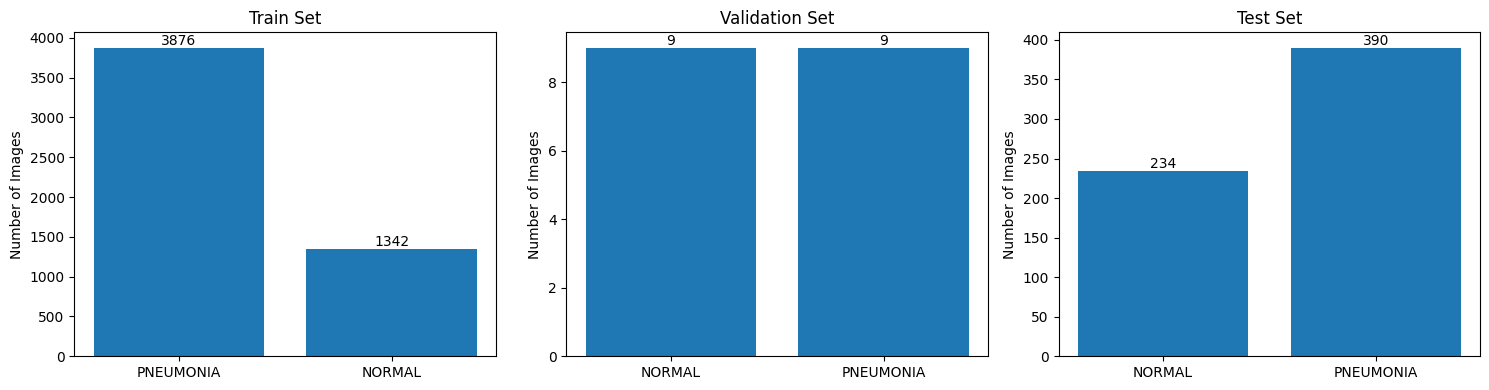

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    ("Train", train_counts),
    ("Validation", val_counts),
    ("Test", test_counts)
]

for ax, (title, counts) in zip(axes, datasets):
    ax.bar(counts.keys(), counts.values())
    ax.set_title(f"{title} Set")
    ax.set_ylabel("Number of Images")

    for i, v in enumerate(counts.values()):
        ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


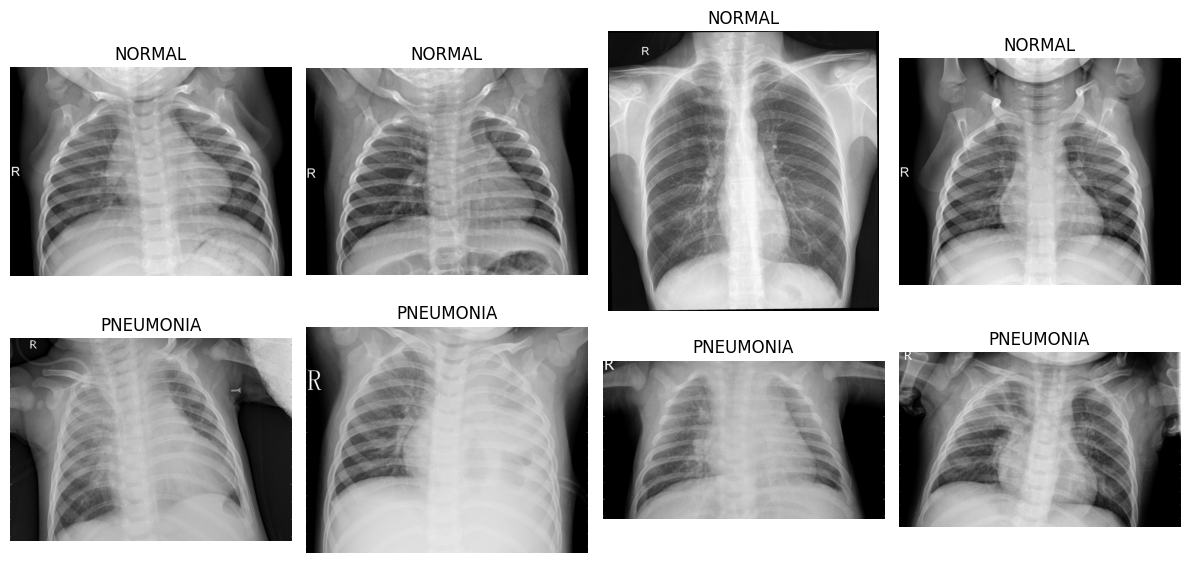

In [8]:
import os
import matplotlib.pyplot as plt
from PIL import Image

def show_samples(folder, samples=4):
    fig, axes = plt.subplots(2, samples, figsize=(12, 6))
    classes = ['NORMAL', 'PNEUMONIA']

    for row, cls in enumerate(classes):
        path = os.path.join(folder, cls)
        images = os.listdir(path)[:samples]

        for col, img_name in enumerate(images):
            img = Image.open(os.path.join(path, img_name))
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].set_title(cls)
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(train_dir)



In [9]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)
 # No augmentation for validation and test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary'
)
# Validation generator
val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary'
)
 # Test generator
test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [10]:
print(train_data.class_indices)


{'NORMAL': 0, 'PNEUMONIA': 1}


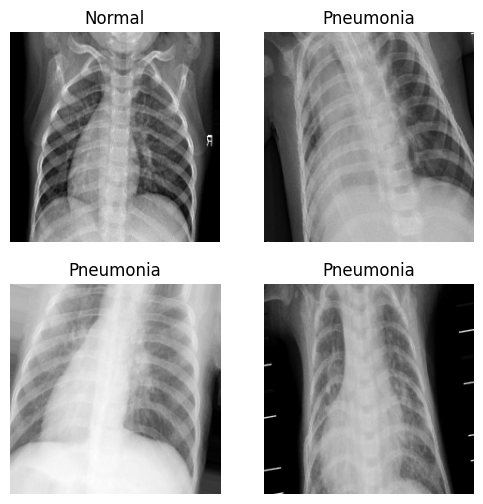

In [11]:
images, labels = next(train_data)

plt.figure(figsize=(6,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i].reshape(224,224), cmap='gray')
    plt.title("Pneumonia" if labels[i]==1 else "Normal")
    plt.axis('off')
plt.show()


# **Model Building**

In [12]:
model = Sequential()

# Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)))
model.add(MaxPooling2D(2,2))

# Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [14]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 2691s 16s/step - accuracy: 0.7642 - loss: 0.5184 - val_accuracy: 0.8125 - val_loss: 0.6867
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 431ms/step - accuracy: 0.8900 - loss: 0.2712 - val_accuracy: 0.7500 - val_loss: 0.7385
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 437ms/step - accuracy: 0.8871 - loss: 0.2635 - val_accuracy: 0.6250 - val_loss: 0.6955
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 430ms/step - accuracy: 0.8980 - loss: 0.2379 - val_accuracy: 0.6875 - val_loss: 0.6331
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 430ms/step - accuracy: 0.9176 - loss: 0.2064 - val_accuracy: 0.6250 - val_loss: 1.3654


### **Graphical representation**

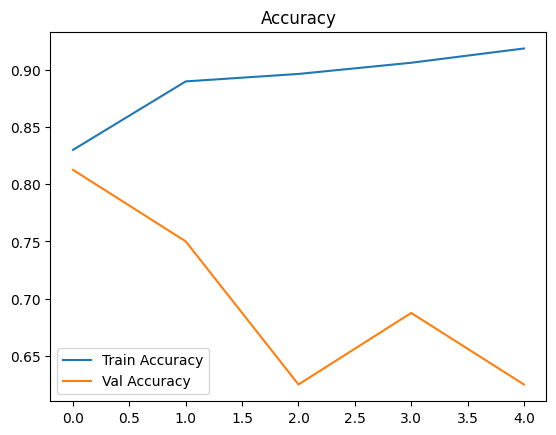

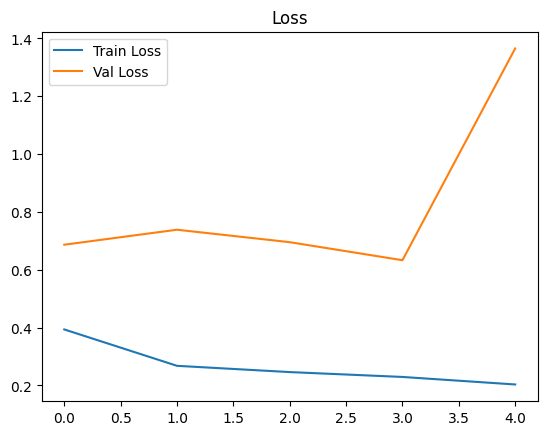

In [16]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()


In [17]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)


20/20 ━━━━━━━━━━━━━━━━━━━━ 385s 20s/step - accuracy: 0.7110 - loss: 0.8881
Test Accuracy: 0.8301281929016113


# **Moldel Evaluation**

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(test_data.classes, y_pred))
print(classification_report(test_data.classes, y_pred))


## **Test model on new sample**

In [21]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/X_ray2.webp"

img = image.load_img(img_path, target_size=(224,224), color_mode='grayscale')
img = image.img_to_array(img) / 255.0
img = img.reshape(1,224,224,1)

prediction = model.predict(img)

if prediction > 0.5:
    print("Pneumonia Detected")
else:
    print("Normal Chest X-ray")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Pneumonia Detected


## **Save final model**

In [ ]:
model.save('pneumonia_detection_model.h5')